In [3]:
import os
import numpy as np
import pandas as pd
import pickle
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold
from skopt import BayesSearchCV
from skopt.space import Real, Integer
import matplotlib.pyplot as plt

def train_model_with_smbo(training_df, test_df, score_name, output_folder):
    os.makedirs(output_folder, exist_ok=True)

    # Drop rows with NaN values in the scores column
    training_df = training_df.dropna(subset=['scores'])
    test_df = test_df.dropna(subset=['scores'])

    # Extract coordinates and scores from training data
    train_coords = np.array([list(coord) for coord in training_df['embeddings']])
    train_scores = training_df['scores'].values

    # Extract coordinates and scores from test data
    test_coords = np.array([list(coord) for coord in test_df['embeddings']])
    test_scores = test_df['scores'].values

    # Determine the range of possible values
    min_score = min(np.min(train_scores), np.min(test_scores))
    max_score = max(np.max(train_scores), np.max(test_scores))
    range_of_values = max_score - min_score

    # Number of folds for cross-validation
    k = 5
    num_permutations = 100

    # Define the hyperparameter search space for SMBO
    search_space = {
        'n_estimators': Integer(50, 300),
        'max_depth': Integer(5, 50),
        'min_samples_split': Integer(2, 10),
        'min_samples_leaf': Integer(1, 4),
        'bootstrap': [True, False]
    }

    # List to store the best models from each permutation
    permutation_metrics = []

    for perm in range(num_permutations):
        kf = KFold(n_splits=k, shuffle=True, random_state=perm)

        # Use BayesSearchCV for hyperparameter optimization within each permutation
        bayes_cv = BayesSearchCV(
            estimator=RandomForestRegressor(random_state=42),
            search_spaces=search_space,
            n_iter=20,  # Number of parameter settings that are sampled
            cv=kf,
            n_jobs=-1,
            random_state=42
        )

        # Fit the model
        bayes_cv.fit(train_coords, train_scores)
        best_model = bayes_cv.best_estimator_

        # Store the trained model
        models = [best_model]

        # Evaluate on the validation set
        r2_scores_train = []
        r2_scores_val = []
        normalized_mse_val_list = []
        mae_max_scores = []
        normalized_mae_train_list = []
        normalized_mse_train_list = []
        mae_max_train_list = []

        for train_index, val_index in kf.split(train_coords):
            X_train, X_val = train_coords[train_index], train_coords[val_index]
            y_train, y_val = train_scores[train_index], train_scores[val_index]

            # Train the model
            best_model.fit(X_train, y_train)

            # Predict on the validation set
            y_val_pred = best_model.predict(X_val)
            y_train_pred = best_model.predict(X_train)
            mse_val = mean_squared_error(y_val, y_val_pred)
            mae_val = mean_absolute_error(y_val, y_val_pred)
            mae_max_val = (mae_val / max_score) * 100
            normalized_mse_val = (mse_val / (range_of_values ** 2)) * 100
            r2_val = r2_score(y_val, y_val_pred)
            r2_train = r2_score(y_train, y_train_pred)

            mae_max_scores.append(mae_max_val)
            normalized_mse_val_list.append(normalized_mse_val)
            r2_scores_val.append(r2_val)
            r2_scores_train.append(r2_train)

            # Normalize errors
            normalized_mae_train = (mean_absolute_error(y_train, y_train_pred) / range_of_values) * 100
            normalized_mse_train = (mean_squared_error(y_train, y_train_pred) / (range_of_values ** 2)) * 100
            mae_max_train = (mean_absolute_error(y_train, y_train_pred) / max_score) * 100
            normalized_mae_train_list.append(normalized_mae_train)
            normalized_mse_train_list.append(normalized_mse_train)
            mae_max_train_list.append(mae_max_train)

        # Record metrics for the permutation
        permutation_metrics.append({
            'models': models,
            'r2_scores_train': r2_scores_train,
            'r2_scores_val': r2_scores_val,
            'normalized_mse_val_list': normalized_mse_val_list,
            'mae_max_scores': mae_max_scores,
            'normalized_mae_train_list': normalized_mae_train_list,
            'normalized_mse_train_list': normalized_mse_train_list,
            'mae_max_train_list': mae_max_train_list,
        })

        # Optionally, you can print the best parameters found
        print(f'Best hyperparameters for permutation {perm}: {bayes_cv.best_params_}')

    # Select the best permutation based on average validation R^2 score
    best_permutation = max(permutation_metrics, key=lambda x: np.mean(x['r2_scores_val']))
    best_models = best_permutation['models']

    # Make predictions on the test data using the ensemble of models from the best permutation
    test_predictions = np.zeros(test_coords.shape[0])
    for model in best_models:
        test_predictions += model.predict(test_coords)
    test_predictions /= len(best_models)

    # Calculate the Mean Squared Error, Mean Absolute Error, and R^2 on the test data
    mse_test = mean_squared_error(test_scores, test_predictions)
    mae_test = mean_absolute_error(test_scores, test_predictions)
    mae_max_test = (mae_test / max_score) * 100
    normalized_mse_test = (mse_test / (range_of_values ** 2)) * 100
    r2_test = r2_score(test_scores, test_predictions)

    # Normalize errors
    normalized_mae_test = (mae_test / range_of_values) * 100
    print(f'{score_name} - Avg Training R^2: {np.mean(best_permutation["r2_scores_train"])}')
    print(f'{score_name} - Avg Normalized Training MSE: {np.mean(best_permutation["normalized_mse_train_list"]):.2f}%, Avg Normalized Training MAE: {np.mean(best_permutation["normalized_mae_train_list"]):.2f}%, Avg MAE_max% Training: {np.mean(best_permutation["mae_max_train_list"]):.2f}%')
    print(f'{score_name} - Test R^2: {r2_test}')
    print(f'{score_name} - Normalized Test MSE: {normalized_mse_test:.2f}%, Normalized Test MAE: {normalized_mae_test:.2f}%, Test MAE_max%: {mae_max_test:.2f}%')

    # Save the models from the best permutation
    for i, model in enumerate(best_models):
        model_path = os.path.join(output_folder, f'{score_name}_model_fold_{i}.pkl')
        with open(model_path, 'wb') as f:
            pickle.dump(model, f)
        print(f'Model {i} saved to {model_path}')

    # Save the validation metrics, including the ensembled test metrics, to a spreadsheet
    metrics_df = pd.DataFrame({
        'Fold': range(1, k + 1),
        'Training R^2': best_permutation['r2_scores_train'],
        'Validation R^2': best_permutation['r2_scores_val'],
        'Normalized Validation MSE (%)': best_permutation['normalized_mse_val_list'],
        'MAE_max%': best_permutation['mae_max_scores'],
    })
    metrics_df['Normalized MAE (%)'] = best_permutation['normalized_mae_train_list']

    # Calculate and append the average training metrics
    avg_training_r2 = np.mean(best_permutation['r2_scores_train'])
    avg_normalized_mae_train = np.mean(best_permutation['normalized_mae_train_list'])
    avg_normalized_mse_train = np.mean(best_permutation['normalized_mse_train_list'])
    avg_mae_max_train = np.mean(best_permutation['mae_max_train_list'])
    metrics_df.loc[k, 'Fold'] = 'Avg Training'
    metrics_df.loc[k, 'Training R^2'] = avg_training_r2
    metrics_df.loc[k, 'Normalized Validation MSE (%)'] = avg_normalized_mse_train
    metrics_df.loc[k, 'MAE_max%'] = avg_mae_max_train
    metrics_df.loc[k, 'Normalized MAE (%)'] = avg_normalized_mae_train

    # Append the ensembled test metrics to the DataFrame
    metrics_df.loc[k + 1, 'Fold'] = 'Test Ensemble'
    metrics_df.loc[k + 1, 'Test R^2'] = r2_test
    metrics_df.loc[k + 1, 'Normalized Validation MSE (%)'] = normalized_mse_test
    metrics_df.loc[k + 1, 'MAE_max%'] = mae_max_test
    metrics_df.loc[k + 1, 'Normalized MAE (%)'] = normalized_mae_test

    # Save to Excel
    metrics_df.to_excel(os.path.join(output_folder, f'{score_name}_validation_metrics.xlsx'), index=False)

    # Visualize the predictions vs. actual scores
    plt.figure(figsize=(10, 6))
    plt.scatter(test_scores, test_predictions, alpha=0.6)
    plt.plot([test_scores.min(), test_scores.max()], [test_scores.min(), test_scores.max()], 'k--', lw=2)
    plt.xlabel('Actual Scores')
    plt.ylabel('Predicted Scores')
    plt.title(f'Actual vs Predicted Scores - {score_name}')
    plt.savefig(os.path.join(output_folder, f'{score_name}_prediction_plot.png'))
    plt.show()

# Assuming training_df and test_df are already defined and contain the necessary data
# train_model_with_smbo(training_df, test_df, 'my_model', 'output_folder')


Found 119 files in /gamma/GIN Dropbox/Chris Foulon/EMUSE/DSD_repro/disco_119
Found 24 files in /gamma/GIN Dropbox/Chris Foulon/EMUSE/DSD_repro/disco_24


1333it [00:29, 45.13it/s]
119it [00:02, 46.80it/s]


The following filenames could not be replaced because they were not found: set()


20it [00:00, 49.43it/s]


Shape of matched embeddings: (119, 2)
Shape of matched embeddings after removing NaNs and Infs: (79, 2)
Setting discrete embedding with shape None
Created heatmap mes_coc
Setting discrete embedding with shape (302, 261)
Created heatmap rescaled and discrete space mes_coc
Type of self.heatmaps[name]: <class 'tools.emuse_utils.Heatmap'>
Discrete space type: <class 'numpy.ndarray'>
Smoothing the discrete space with a sigma of 20
Shape of the smoothed space: (79, 302, 261)
Sigma tuple: (0, 20, 20)
Shape of the smoothed n+1 dim discrete space: (79, 302, 261)
Heatmap mes_coc created
Max value in the smoothed_nplusone_dim_discrete_space: 1.0


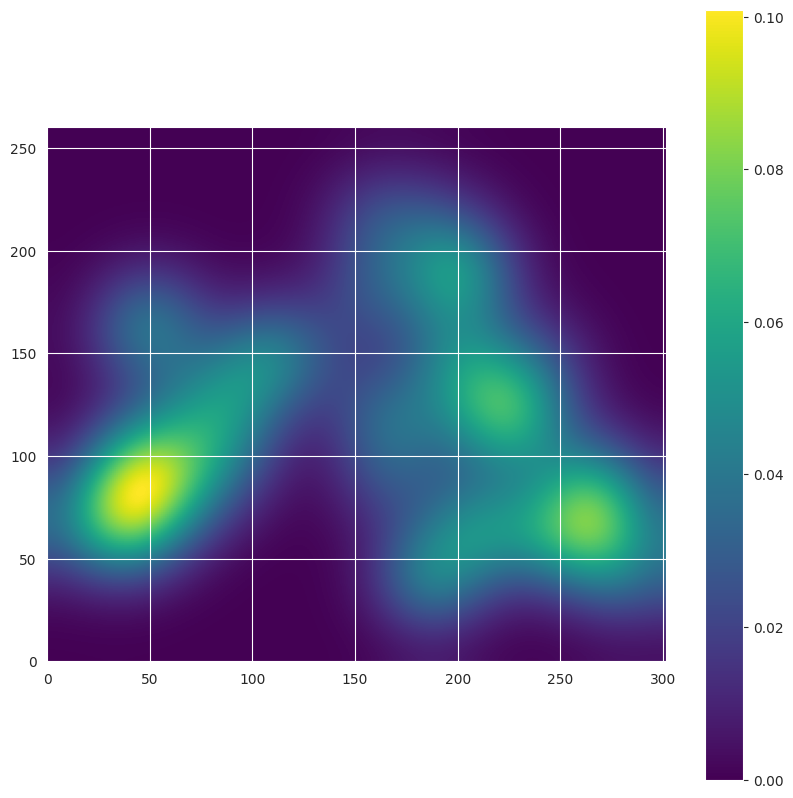

Statistics for mes_coc computed


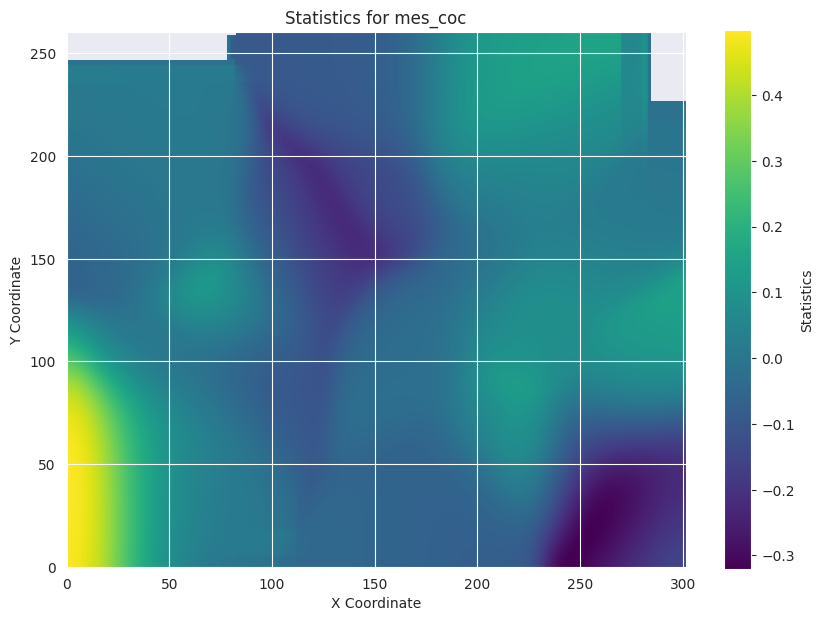

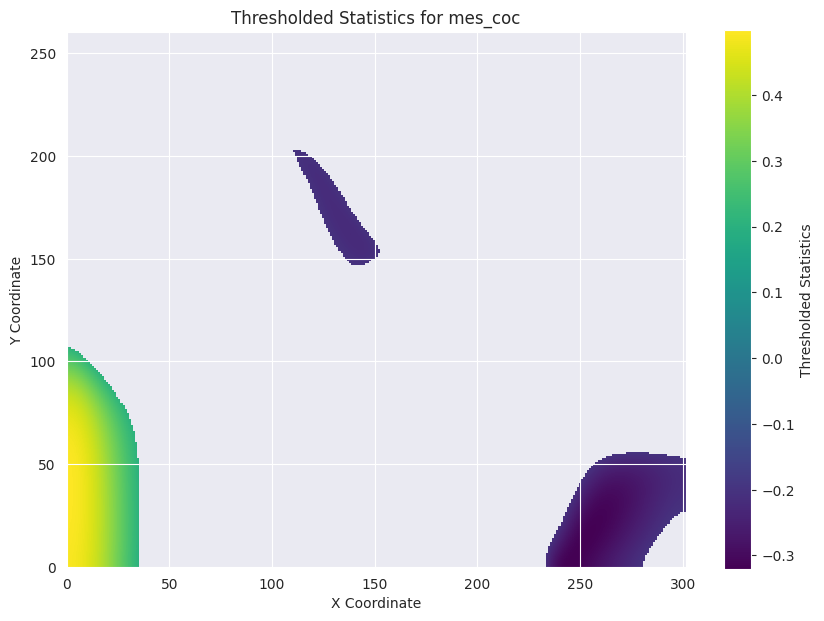

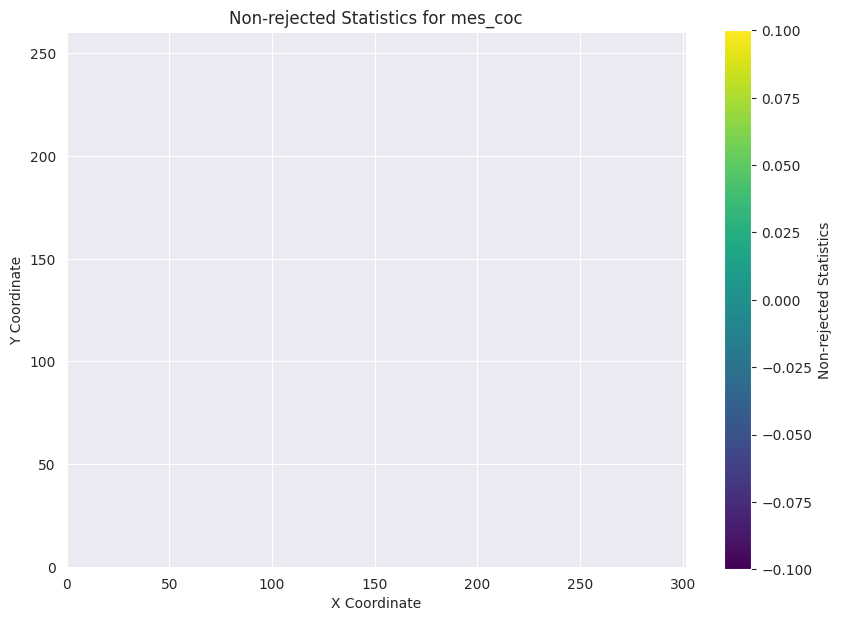

Found 3 clusters


100%|██████████| 902629/902629 [02:46<00:00, 5406.54it/s]


Shape of the maps: (902629,)


100%|██████████| 902629/902629 [02:56<00:00, 5101.79it/s]


Shape of the maps: (902629,)


100%|██████████| 902629/902629 [02:45<00:00, 5441.27it/s]


Shape of the maps: (902629,)


/tmp/ipykernel_322215/3951562122.py:205: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('gist_rainbow')


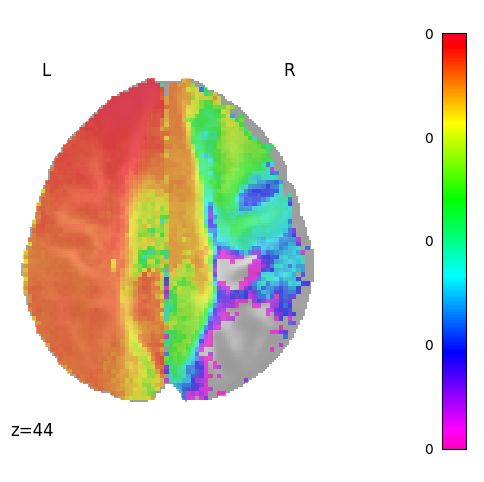

/home/chrisfoulon/miniconda3/lib/python3.11/site-packages/numpy/ma/core.py:2820: UserWarning: Warning: converting a masked element to nan.
  _data = np.array(data, dtype=dtype, copy=copy,


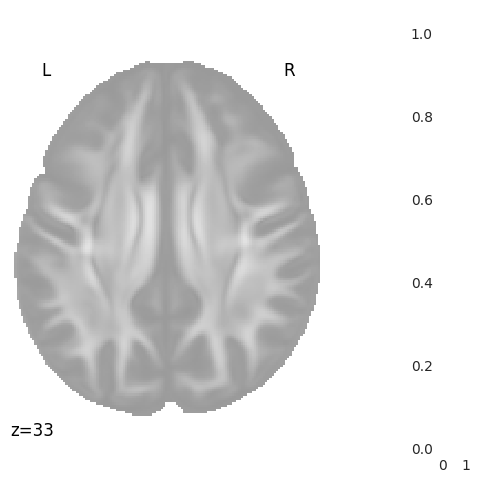

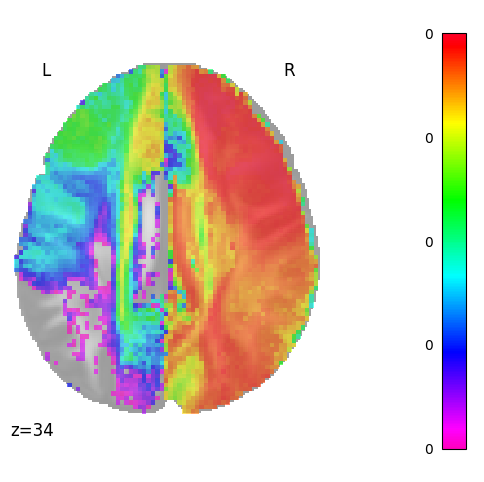

mes_coc - Avg Training R^2: 0.8422164194076378
mes_coc - Avg Normalized Training MSE: 0.15%, Avg Normalized Training MAE: 2.60%, Avg MAE_max% Training: 4.24%
mes_coc - Test R^2: 0.3501653392945847
mes_coc - Normalized Test MSE: 1.51%, Normalized Test MAE: 9.13%, Test MAE_max%: 14.85%
Model 0 saved to /gamma/Dropbox (GIN)/EMUSE/DSD_repro/emuse_results_all_scores_100_permutation_better_plots/mes_coc/mes_coc_model_fold_0.pkl
Model 1 saved to /gamma/Dropbox (GIN)/EMUSE/DSD_repro/emuse_results_all_scores_100_permutation_better_plots/mes_coc/mes_coc_model_fold_1.pkl
Model 2 saved to /gamma/Dropbox (GIN)/EMUSE/DSD_repro/emuse_results_all_scores_100_permutation_better_plots/mes_coc/mes_coc_model_fold_2.pkl
Model 3 saved to /gamma/Dropbox (GIN)/EMUSE/DSD_repro/emuse_results_all_scores_100_permutation_better_plots/mes_coc/mes_coc_model_fold_3.pkl
Model 4 saved to /gamma/Dropbox (GIN)/EMUSE/DSD_repro/emuse_results_all_scores_100_permutation_better_plots/mes_coc/mes_coc_model_fold_4.pkl


/gamma/GIN Dropbox/Chris Foulon/EMUSE/package/emuse/tools/stats_utils.py:300: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'Avg Training' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  metrics_df.loc[k, 'Fold'] = 'Avg Training'


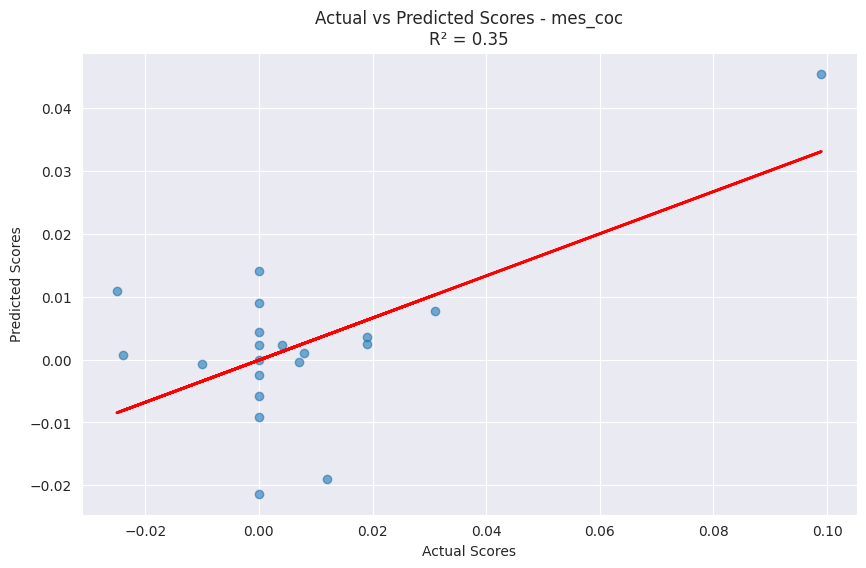

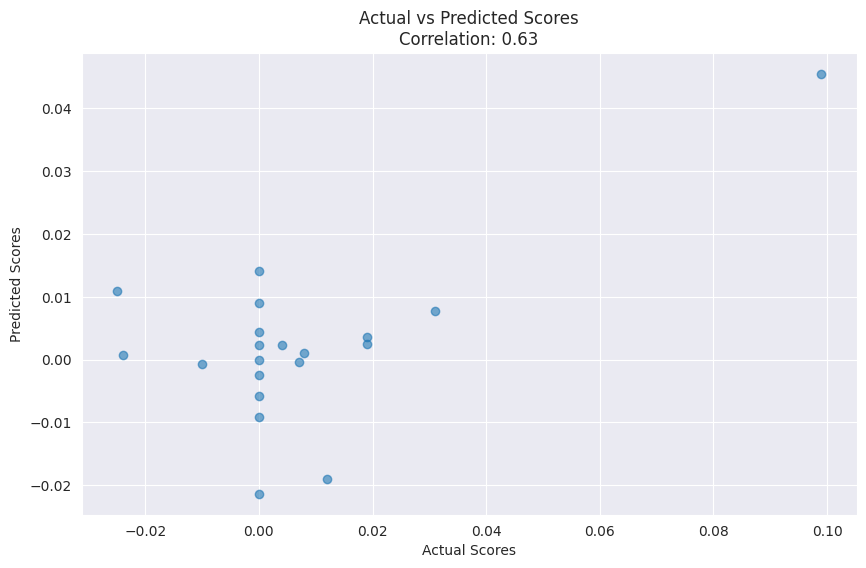

In [26]:
from bcblib.tools.visualisation import plot_multiple_rois
from tools.stats_utils import create_cluster_representative_maps
import joblib
from matplotlib import pyplot as plt
import nibabel as nib

"""
EMUSE is separated in 3 steps:
1. Training a UMAP on a large dataset
2. Create a DiscreateLatentSpace object and heatmaps to show the correlations in the space with the scores
3. Train a predictive model on the latent space to predict the different scores
"""
from pathlib import Path

import pandas as pd
import numpy as np

from bcblib.tools.general_utils import parse_file_list_argument
from tools.inputs_utils import nifti_dataset_to_matrix
from tools.UMAP_utils import train_and_save_umap_and_embeddings
from tools.emuses_utils import DiscreteLatentSpace, compute_stats_on_smoothed_nplusone_dim_discrete_space
from tools.stats_utils import train_model

"""
INPUTS
"""

disco_folder = '/gamma/Dropbox (GIN)/EMUSE/DSD_repro/disco_1333'
output_folder = '/gamma/Dropbox (GIN)/EMUSE/DSD_repro/emuse_results_all_scores_100_permutation_better_plots'
# create the output_folder if it does not exist
Path(output_folder).mkdir(parents=True, exist_ok=True)

# list nifti files in lesions_folder
disco_list = [p for p in Path(disco_folder).iterdir() if p.is_file()]

first_image = nib.load(disco_list[0])
original_shape = first_image.shape
original_affine = first_image.affine

# load the spreadsheet with the scores for the training dataset
training_spreadsheet = pd.read_excel(r'/gamma/Dropbox (GIN)/EMUSE/DSD_repro/validation_set/dataset_measured_complete.xlsx', header=0, index_col=0) # indices are the test names, columns are filenames (without extension)
training_files_folder = r'/gamma/Dropbox (GIN)/EMUSE/DSD_repro/disco_119/'
training_files_list = parse_file_list_argument(training_files_folder)

# now the input for the validation set for the predictions
test_spreadsheet = pd.read_excel(r'/gamma/Dropbox (GIN)/EMUSE/DSD_repro/validation_set/dataset_measured_20.xlsx', header=0, index_col=0) # indices are the test names, columns are filenames (without extension)

# Parse the file list
test_files_folder = r'/gamma/Dropbox (GIN)/EMUSE/DSD_repro/disco_24/'
test_files_list = parse_file_list_argument(test_files_folder)


# disco_input_matrix with nifti_dataset_to_matrix
"""
PREPROCESSING
"""
# preproc umap training
disco_input_matrix = nifti_dataset_to_matrix(disco_list)

# preproc score training dataset
# TODO this is specific to this dataset. Need to find a more general way to do this
training_spreadsheet = training_spreadsheet.T
filename_list = training_spreadsheet.index
# find each filename in the training_files_list
for filename in filename_list:
    for training_file in training_files_list:
        if filename in training_file:
            training_spreadsheet.rename(index={filename: training_file}, inplace=True)
            break

# create an input_matrix with the indices (file paths now) which are in the right order
training_input_matrix = nifti_dataset_to_matrix(training_spreadsheet.index)

# preproc score test dataset

# Match the filenames with the file paths
test_spreadsheet = test_spreadsheet.T
test_filename_list = test_spreadsheet.index
# List to store the filenames that were matched
matched_filenames = []

for filename in test_filename_list:
    # find each filename in the test_files_list and replace the filename with the full path
    for file_path in test_files_list:
        if Path(file_path).name.lower() == filename.lower():  # convert both to lower case for comparison
            test_spreadsheet = test_spreadsheet.rename(index={filename: file_path})
            matched_filenames.append(filename)
            break

# Find the filenames that could not be replaced
not_matched_filenames = set(test_filename_list) - set(matched_filenames)

print(f"The following filenames could not be replaced because they were not found: {not_matched_filenames}")
# Create an input matrix with the matched file paths
test_input_matrix = nifti_dataset_to_matrix(test_spreadsheet.index)

"""
TRAINING UMAP
"""
umap_path = Path(output_folder, 'disco_umap_model_joblib1.3.1.joblib')
embeddings_path = Path(output_folder, 'disco_embeddings.npy')
if not Path(umap_path).exists():
    trained_umap, embeddings, umap_path, embeddings_path = train_and_save_umap_and_embeddings(disco_input_matrix, output_folder, 'disco', random_state=42)
else:
    trained_umap = joblib.load(umap_path)
    embeddings = np.load(embeddings_path)

"""
CREATE DISCRETE SPACE AND HEATMAPS
5% margins around the embeddings
<10% of overlap between the data points
"""
# umap_path = '/gamma/Dropbox (GIN)/EMUSE/DSD_repro/emuse_results/disco_umap_model_joblib1.3.1.joblib'
if not Path(output_folder, 'disco_dls.dls').exists():
    disco_dls = DiscreteLatentSpace(trained_umap, margin=5) # could use the umap_path
    
    # rescale the embedding
    disco_dls.rescale_embedding(disco_dls.raw_embeddings)
    
    # create the discrete space
    disco_dls.create_discrete_space(disco_dls.rescaled_embeddings, 15)
    
    
    # create the heatmaps
    # First we need to transform the training_input_matrix to the latent space
    # TODO the transform could be done at 2 places: 1) for each heatmap we transform the data, 2) all the heatmaps share the same set of transformed data (embeddings)
    training_embeddings = disco_dls.trained_umap.transform(training_input_matrix)
    
    np.save(Path(output_folder, 'training_embeddings.npy'), training_embeddings)
    
    # Get the embeddings using the trained UMAP for the test dataset
    test_embeddings = disco_dls.trained_umap.transform(test_input_matrix)
    
    np.save(Path(output_folder, 'test_embeddings.npy'), test_embeddings)

    # save the DLS object
    disco_dls.save(Path(output_folder, 'disco_dls.dls'))
else:
    disco_dls = DiscreteLatentSpace.load(Path(output_folder, 'disco_dls.dls'))
    training_embeddings = np.load(Path(output_folder, 'training_embeddings.npy'))
    test_embeddings = np.load(Path(output_folder, 'test_embeddings.npy'))
# training_embeddings = np.load('/gamma/Dropbox (GIN)/EMUSE/DSD_repro/emuse_results/training_embeddings.npy')
# for score_tag in training_spreadsheet.columns:
for score_tag in ['mes_coc']:
    score_output_folder = Path(output_folder, score_tag)
    Path(score_output_folder).mkdir(parents=True, exist_ok=True)
    scores = training_spreadsheet[score_tag].to_numpy()
    training_df = pd.DataFrame(data={'embeddings': [tuple(coord) for coord in training_embeddings]})
    training_df['scores'] = scores
    if score_tag in disco_dls.heatmaps:
        disco_dls.delete_heatmap(score_tag)
    if score_tag not in disco_dls.heatmaps:
        disco_dls.create_heatmap_spaces(training_df, score_tag, smoothing_fwhm=None, smoothing_sigma=20)

    print(f'Heatmap {score_tag} created')

    disco_dls.plot_heatmap(score_tag, output_folder=score_output_folder)

    # Now we compute the correlations and display the heatmaps for each score
    statistics, pvalues, corrected_pvalues, reject = compute_stats_on_smoothed_nplusone_dim_discrete_space(disco_dls.heatmaps[score_tag], disco_dls.heatmaps[score_tag].scores, correction_method='holm')

    print(f'Statistics for {score_tag} computed')
    # Plot the statistics
    plt.figure(figsize=(10, 7))
    plt.imshow(statistics.T, cmap='viridis', origin='lower')
    plt.colorbar(label='Statistics')
    plt.title(f'Statistics for {score_tag}')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.savefig(Path(score_output_folder, f'raw_statistics_{score_tag}.png'))
    plt.show()

    # threshold the |statistics| > 0.2 and show the space
    thresholded_statistics = np.where(np.abs(statistics) < 0.2, np.nan, statistics)
    plt.figure(figsize=(10, 7))
    plt.imshow(thresholded_statistics.T, cmap='viridis', origin='lower')
    plt.colorbar(label='Thresholded Statistics')
    plt.title(f'Thresholded Statistics for {score_tag}')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.savefig(Path(score_output_folder, f'thresholded_statistics_{score_tag}.png'))
    plt.show()

    # Create a mask for the rejected hypotheses
    reject_mask = np.ma.masked_where(corrected_pvalues > 0.05, statistics)

    # Plot the statistics that are not rejected
    plt.figure(figsize=(10, 7))
    plt.imshow(reject_mask.T, cmap='viridis', origin='lower')
    plt.colorbar(label='Non-rejected Statistics')
    plt.title(f'Non-rejected Statistics for {score_tag}')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.savefig(Path(score_output_folder, f'non_rejected_statistics_{score_tag}.png'))
    plt.show()
    
    # stat_map, pval_map, effect_size_map, centroids = create_cluster_representative_maps(thresholded_statistics, disco_dls.discrete_embeddings, disco_input_matrix, original_shape, test_name='mann-whitney') 
    stat_map, pval_map, effect_size_map, centroids = create_cluster_representative_maps(thresholded_statistics, disco_dls.discrete_embeddings, disco_input_matrix, original_shape, test_name='mann-whitney')
    
    overlay_path = '//data/FSL_HCP1065_FA_1mm.nii.gz'

    # plot_multiple_rois(stat_map, original_affine, output_stat_maps_folder, 'stat_map_')
    # plot_multiple_rois(pval_map, original_affine, output_stat_maps_folder, 'pval_map_')
    # colorbar should be the inverted gist_rainbow
    cmap = plt.cm.get_cmap('gist_rainbow')
    inverted_cmap = cmap.reversed()
    prefix_with_centroids_list = [f'effect_size_map_{centroid[0]}_{centroid[1]}_' for centroid in centroids]
    plot_multiple_rois(effect_size_map, original_affine, overlay_path, score_output_folder, prefix_with_centroids_list, image_mask=True, threshold=0.1, cmap=inverted_cmap, alpha=0.6)

    # now train and validate the predictive model
    test_scores = test_spreadsheet[score_tag].to_numpy()
    test_df = pd.DataFrame(data={'embeddings': [tuple(coord) for coord in test_embeddings]})
    test_df['scores'] = test_scores

    # train_model_with_smbo(training_df, test_df, score_tag, output_folder)
    train_model(training_df, test_df, score_tag, score_output_folder)


['effect_size_map_15.95406145421357_46.242166108913906_', 'effect_size_map_131.61590145576707_171.95856662933932_', 'effect_size_map_268.78613314936183_27.15315626077958_']
3


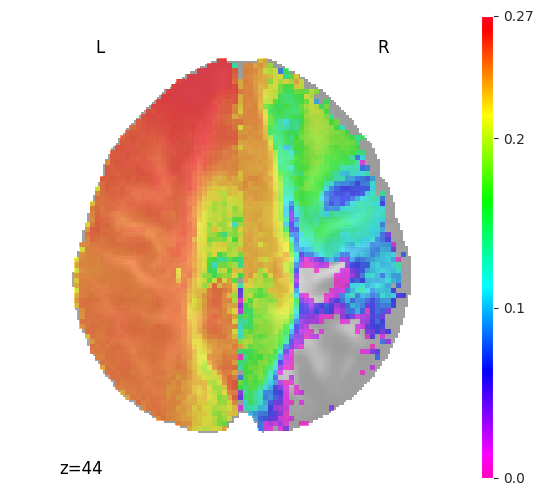

/home/chrisfoulon/miniconda3/lib/python3.11/site-packages/numpy/ma/core.py:2820: UserWarning: Warning: converting a masked element to nan.
  _data = np.array(data, dtype=dtype, copy=copy,


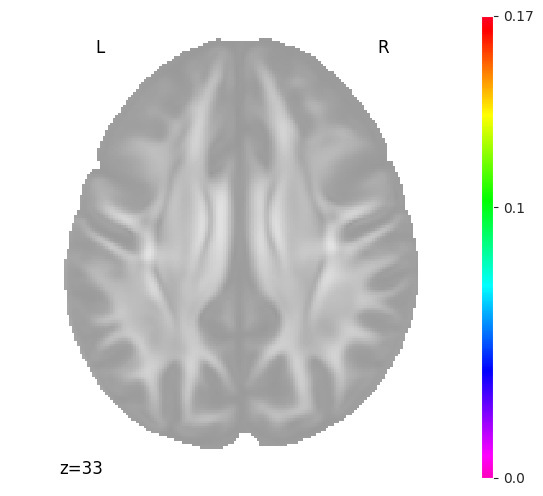

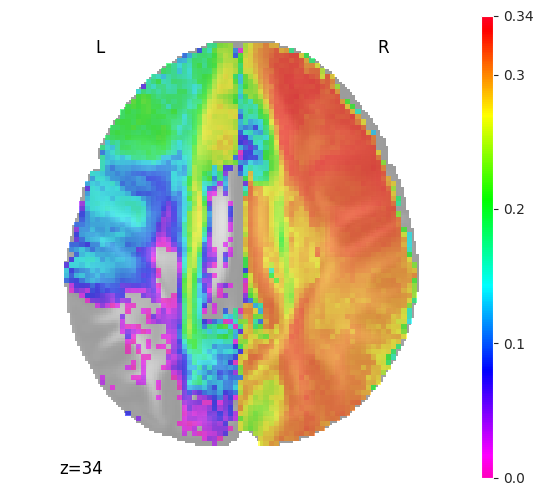

mes_coc - Avg Training R^2: 0.8422164194076378
mes_coc - Avg Normalized Training MSE: 0.15%, Avg Normalized Training MAE: 2.60%, Avg MAE_max% Training: 4.24%
mes_coc - Test R^2: 0.3501653392945847
mes_coc - Normalized Test MSE: 1.51%, Normalized Test MAE: 9.13%, Test MAE_max%: 14.85%
Model 0 saved to /gamma/Dropbox (GIN)/EMUSE/DSD_repro/emuse_results_all_scores_100_permutation_better_plots/mes_coc/mes_coc_model_fold_0.pkl
Model 1 saved to /gamma/Dropbox (GIN)/EMUSE/DSD_repro/emuse_results_all_scores_100_permutation_better_plots/mes_coc/mes_coc_model_fold_1.pkl
Model 2 saved to /gamma/Dropbox (GIN)/EMUSE/DSD_repro/emuse_results_all_scores_100_permutation_better_plots/mes_coc/mes_coc_model_fold_2.pkl
Model 3 saved to /gamma/Dropbox (GIN)/EMUSE/DSD_repro/emuse_results_all_scores_100_permutation_better_plots/mes_coc/mes_coc_model_fold_3.pkl
Model 4 saved to /gamma/Dropbox (GIN)/EMUSE/DSD_repro/emuse_results_all_scores_100_permutation_better_plots/mes_coc/mes_coc_model_fold_4.pkl


/gamma/GIN Dropbox/Chris Foulon/EMUSE/package/emuse/tools/stats_utils.py:300: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'Avg Training' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  metrics_df.loc[k, 'Fold'] = 'Avg Training'


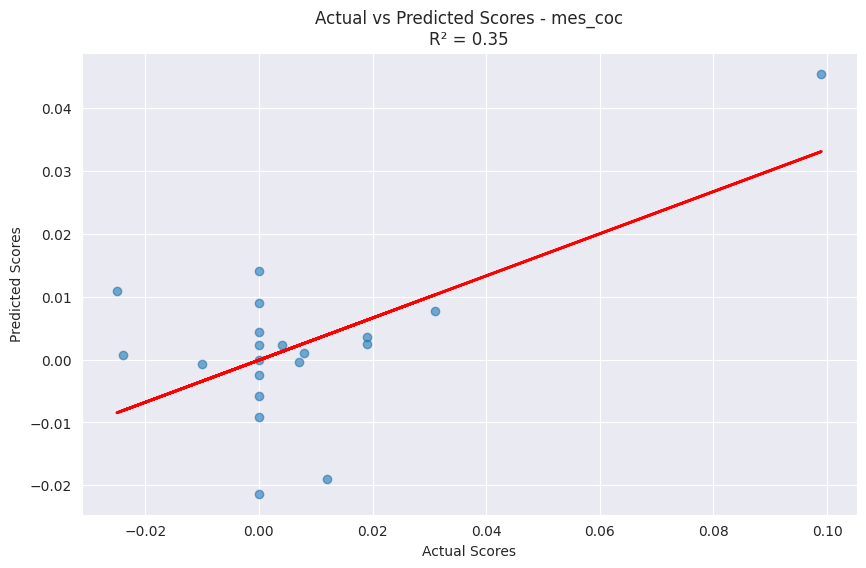

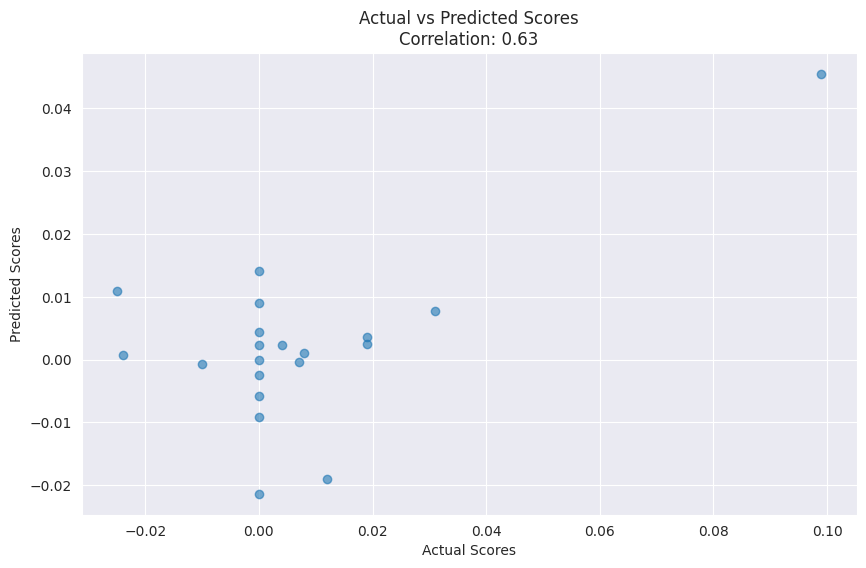

In [37]:
# reload plot_multiple_rois
import importlib
import bcblib.tools.visualisation

importlib.reload(bcblib)

from bcblib.tools.visualisation import plot_multiple_rois

print(prefix_with_centroids_list)
print(len(effect_size_map))

plot_multiple_rois(effect_size_map, original_affine, overlay_path, score_output_folder, prefix_with_centroids_list, image_mask=True, threshold=0.1, cmap=inverted_cmap, alpha=0.6)

# now train and validate the predictive model
test_scores = test_spreadsheet[score_tag].to_numpy()
test_df = pd.DataFrame(data={'embeddings': [tuple(coord) for coord in test_embeddings]})
test_df['scores'] = test_scores

# train_model_with_smbo(training_df, test_df, score_tag, output_folder)
train_model(training_df, test_df, score_tag, score_output_folder)

In [9]:
import pandas as pd
from pathlib import Path

def aggregate_performance_metrics(output_folder):
    # Convert the output folder to a Path object
    output_path = Path(output_folder)

    # Find all the validation metrics files in subfolders
    metric_files = output_path.rglob('*_validation_metrics.xlsx')

    # Initialize lists to store results
    all_metrics = []
    summary_metrics = []

    for metric_file in metric_files:
        # Load the current metric file
        df = pd.read_excel(metric_file)
        score_name = metric_file.stem.split('_validation_metrics')[0]
        df['Score'] = score_name

        # Append the detailed metrics to the list
        all_metrics.append(df)

        # Calculate summary metrics for the current score
        avg_training_r2 = df.loc[df['Fold'] == 'Avg Training', 'Training R^2'].values[0]
        avg_normalized_mae_train = df.loc[df['Fold'] == 'Avg Training', 'Normalized MAE (%)'].values[0]
        avg_normalized_mse_train = df.loc[df['Fold'] == 'Avg Training', 'Normalized Validation MSE (%)'].values[0]
        avg_mae_max_train = df.loc[df['Fold'] == 'Avg Training', 'MAE_max%'].values[0]
        test_r2 = df.loc[df['Fold'] == 'Test Ensemble', 'Test R^2'].values[0]
        normalized_mae_test = df.loc[df['Fold'] == 'Test Ensemble', 'Normalized MAE (%)'].values[0]
        normalized_mse_test = df.loc[df['Fold'] == 'Test Ensemble', 'Normalized Validation MSE (%)'].values[0]
        test_mae_max = df.loc[df['Fold'] == 'Test Ensemble', 'MAE_max%'].values[0]

        summary = {
            'Score': score_name,
            'Avg Training R^2': avg_training_r2,
            'Avg Normalized Training MAE (%)': avg_normalized_mae_train,
            'Avg Normalized Training MSE (%)': avg_normalized_mse_train,
            'Avg MAE_max% Training': avg_mae_max_train,
            'Test R^2': test_r2,
            'Normalized Test MAE (%)': normalized_mae_test,
            'Normalized Test MSE (%)': normalized_mse_test,
            'Test MAE_max%': test_mae_max
        }
        summary_metrics.append(summary)

        # Check if Test R^2 > 0.2 and print score name
        if test_r2 > 0.2:
            print(f"Score with Test R^2 > 0.2: {score_name} : {test_r2}")

    # Combine all the detailed metrics into a single DataFrame
    detailed_metrics_df = pd.concat(all_metrics, ignore_index=True)

    # Combine all the summary metrics into a single DataFrame
    summary_metrics_df = pd.DataFrame(summary_metrics)

    # Save the combined detailed metrics to a spreadsheet
    detailed_metrics_df.to_excel(output_path / 'aggregated_detailed_metrics.xlsx', index=False)

    # Save the summary metrics to a spreadsheet
    summary_metrics_df.to_excel(output_path / 'aggregated_summary_metrics.xlsx', index=False)

    # Print the summary metrics
    print("Aggregated Summary Metrics:")
    # Drop the 'Score' column
    summary_metrics_df_without_scores = summary_metrics_df.drop(columns=['Score'])

    # Calculate and print the average of all the metrics
    average_metrics = summary_metrics_df_without_scores.mean()
    print(average_metrics)

# Example usage:
aggregate_performance_metrics(output_folder)


Score with Test R^2 > 0.2: rpegs : 0.3374576018120651
Score with Test R^2 > 0.2: mes_coc_original : 0.2996653542918782
Score with Test R^2 > 0.2: mes_coc : 0.3501653392945847
Score with Test R^2 > 0.2: laragrasp : 0.3869380680892653
Score with Test R^2 > 0.2: raragrasp : 0.3897417680060653
Score with Test R^2 > 0.2: larapinch : 0.3683281876832845
Score with Test R^2 > 0.2: raragrip : 0.3647780607814763
Score with Test R^2 > 0.2: rarapinch : 0.4154113750806969
Score with Test R^2 > 0.2: laragrip : 0.3562852717391306
Score with Test R^2 > 0.2: reading_comp_raw : 0.291696125984252
Score with Test R^2 > 0.2: sip_body : 0.2806662605124137
Score with Test R^2 > 0.2: reading_raw : 0.2134626175869118
Score with Test R^2 > 0.2: rshflex : 0.370633609341717
Score with Test R^2 > 0.2: sip_com : 0.2761297784684499
Score with Test R^2 > 0.2: bvmt_imt : 0.2555444279816432
Aggregated Summary Metrics:
Avg Training R^2                    0.831833
Avg Normalized Training MAE (%)     5.866416
Avg Normaliz

In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.model_selection import RepeatedKFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import make_scorer, mean_absolute_error, r2_score

test_output_folder = '/gamma/Dropbox (GIN)/EMUSE/DSD_repro/models_test_output'
Path(test_output_folder).mkdir(parents=True, exist_ok=True)

# Drop rows with NaN values in the scores column
training_df = training_df.dropna(subset=['scores'])
test_df = test_df.dropna(subset=['scores'])

# Define models to compare
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'Support Vector Machine': SVR(),
    'Gradient Boosting': GradientBoostingRegressor(),
    'k-Nearest Neighbors': KNeighborsRegressor()
}

# Define evaluation metrics
def normalized_mae(y_true, y_pred):
    return (mean_absolute_error(y_true, y_pred) / (y_true.max() - y_true.min())) * 100

scoring = {
    'Normalized MAE': make_scorer(normalized_mae),
    'R2': make_scorer(r2_score)
}

# Split data into training and test sets
train_coords = np.array([list(coord) for coord in training_df['embeddings']])
train_scores = training_df['scores'].values
test_coords = np.array([list(coord) for coord in test_df['embeddings']])
test_scores = test_df['scores'].values

# Determine the range of possible values for normalization
range_of_values = max(np.max(train_scores), np.max(test_scores)) - min(np.min(train_scores), np.min(test_scores))

# Use repeated k-fold cross-validation
cv = RepeatedKFold(n_splits=5, n_repeats=100, random_state=42)

# Evaluate each model
results = []
for name, model in models.items():
    cv_results = cross_val_score(model, train_coords, train_scores, cv=cv, scoring=scoring['Normalized MAE'])
    mean_cv_mae = np.mean(cv_results)
    std_cv_mae = np.std(cv_results)

    model.fit(train_coords, train_scores)
    test_predictions = model.predict(test_coords)
    test_mae = normalized_mae(test_scores, test_predictions)
    test_r2 = r2_score(test_scores, test_predictions)

    results.append({
        'Model': name,
        'Mean CV MAE%': mean_cv_mae,
        'Std CV MAE%': std_cv_mae,
        'Test MAE%': test_mae,
        'Test R2': test_r2
    })

results_df = pd.DataFrame(results)
print(f'Models comparison for {score_tag}')
print(results_df)

# Save results to Excel
results_df.to_excel(os.path.join(test_output_folder, 'model_comparison_results.xlsx'), index=False)


Models comparison for word_raw
                    Model  Mean CV MAE%  Std CV MAE%  Test MAE%   Test R2
0       Linear Regression     26.161162     6.487130   8.180439 -0.071707
1        Ridge Regression     26.159666     6.486837   8.180284 -0.071693
2        Lasso Regression     25.653175     6.714084   8.045570 -0.055865
3  Support Vector Machine     26.272216     5.859358   8.162928 -0.104432
4       Gradient Boosting     29.227460     9.182025   8.481270 -0.017285
5     k-Nearest Neighbors     28.846761     8.563390   8.280000 -0.035637


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Train input shape: (548, 43), Train scores shape: (548, 1)
Test input shape: (137, 43), Test scores shape: (137, 1)
Train input value shape: (548, 43), Train scores value shape: (548, 1)
Test input value shape: (137, 43), Test scores value shape: (137, 1)
There is an overlap of 4.20% points in the discrete space
The number of cells in the discrete space is 184458
The shape of the discrete space is (433, 426)
Maximum in each dimension: 14.39889144897461


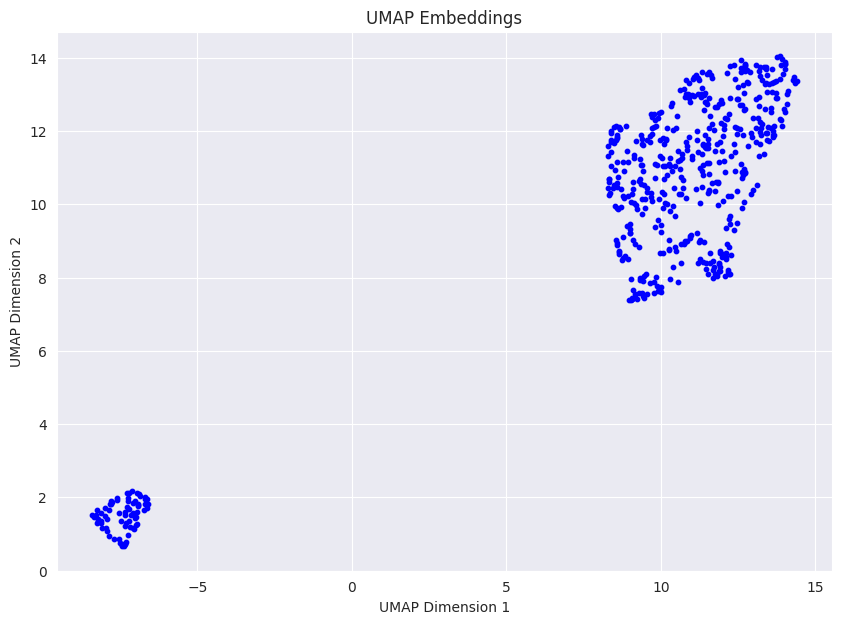

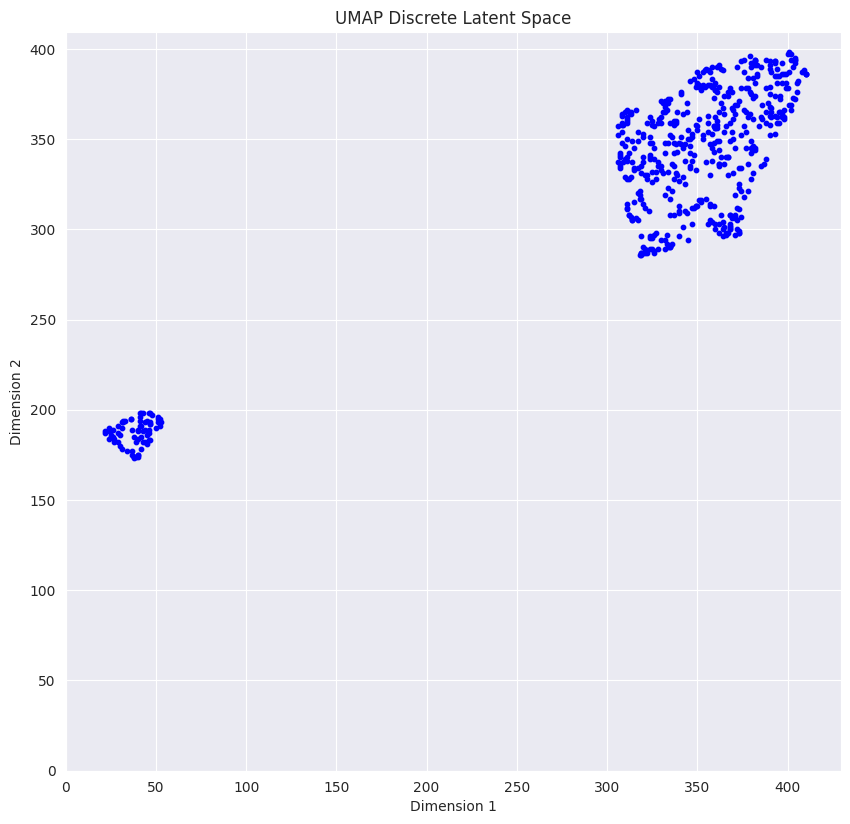

Shape of matched embeddings: (548, 2)
Shape of matched embeddings after removing NaNs and Infs: (548, 2)
Setting discrete embedding with shape None
Created heatmap Attractive
Setting discrete embedding with shape (433, 426)
Created heatmap rescaled and discrete space Attractive
Type of self.heatmaps[name]: <class 'tools.emuse_utils.Heatmap'>
Discrete space type: <class 'numpy.ndarray'>
Smoothing the discrete space with a sigma of 20
Shape of the smoothed space: (548, 433, 426)
Sigma tuple: (0, 20, 20)
Shape of the smoothed n+1 dim discrete space: (548, 433, 426)
Heatmap Attractive created
Max value in the smoothed_nplusone_dim_discrete_space: 1.0


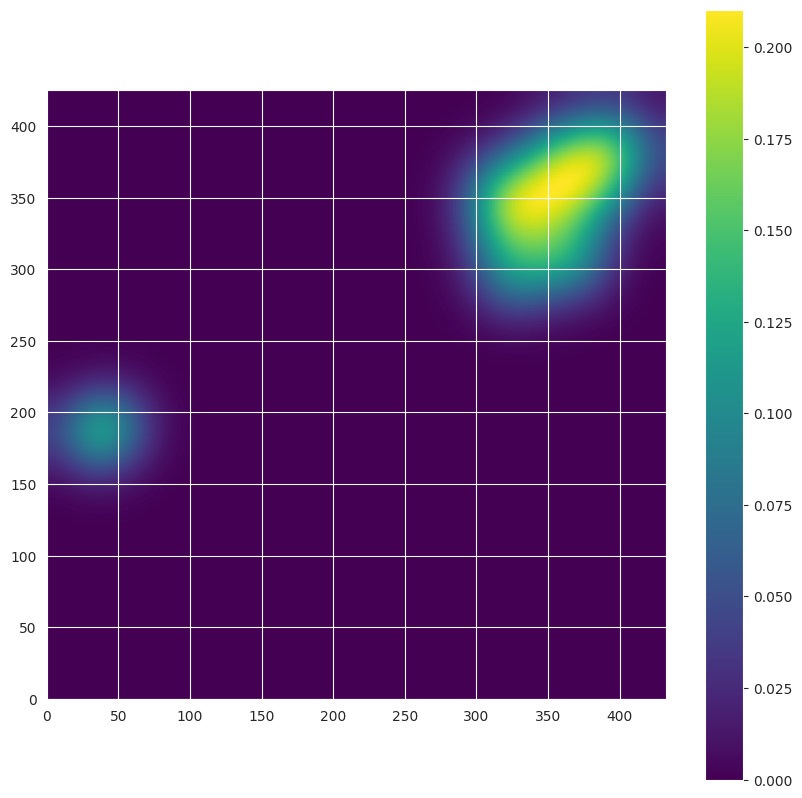

Statistics for Attractive computed


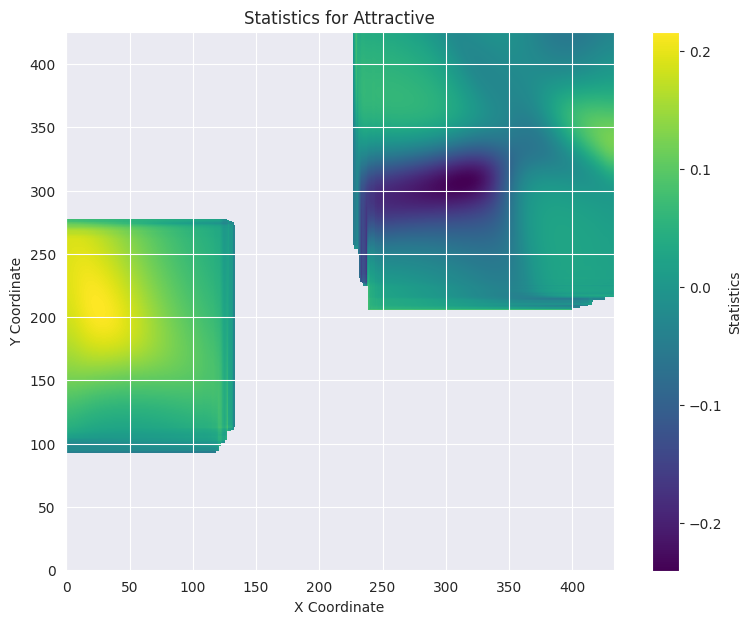

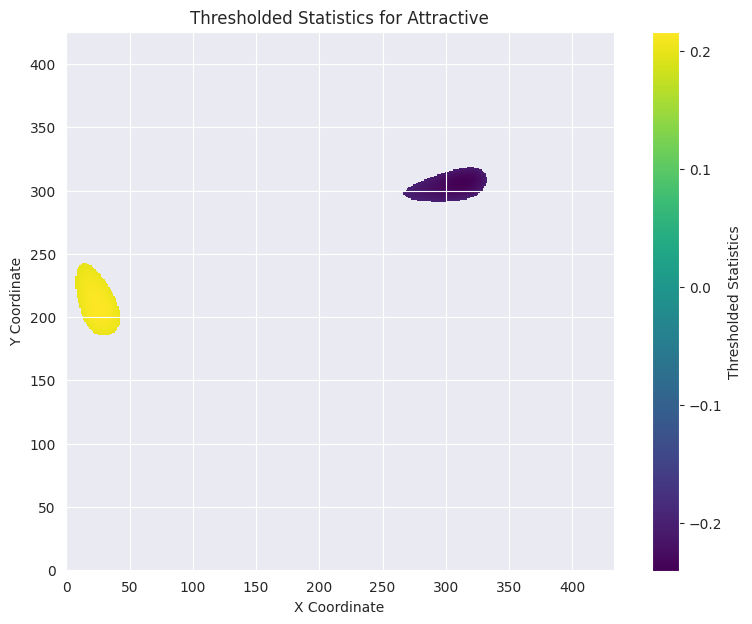

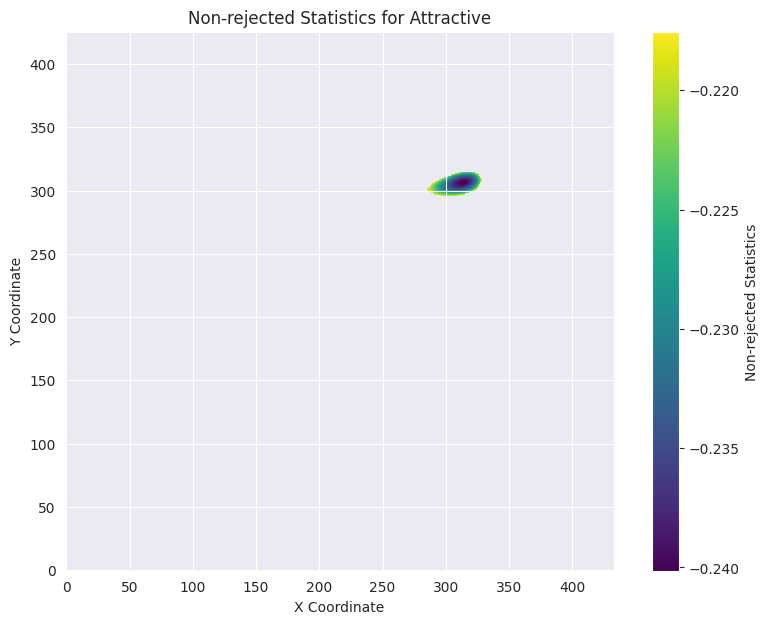

Found 2 clusters


100%|██████████| 43/43 [00:00<00:00, 4977.78it/s]


Shape of the maps: (43,)


100%|██████████| 43/43 [00:00<00:00, 4818.59it/s]


Shape of the maps: (43,)
Attractive - Avg Training R^2: 0.8496522430405582
Attractive - Avg Normalized Training MSE: 0.56%, Avg Normalized Training MAE: 5.98%, Avg MAE_max% Training: 4.33%
Attractive - Test R^2: -0.13026187786379406
Attractive - Normalized Test MSE: 4.57%, Normalized Test MAE: 17.55%, Test MAE_max%: 12.69%
Model 0 saved to /gamma/Dropbox (GIN)/EMUSE/faces/res_EMUSE/Attractive/random_forest/Attractive_model_fold_0.pkl
Model 1 saved to /gamma/Dropbox (GIN)/EMUSE/faces/res_EMUSE/Attractive/random_forest/Attractive_model_fold_1.pkl
Model 2 saved to /gamma/Dropbox (GIN)/EMUSE/faces/res_EMUSE/Attractive/random_forest/Attractive_model_fold_2.pkl
Model 3 saved to /gamma/Dropbox (GIN)/EMUSE/faces/res_EMUSE/Attractive/random_forest/Attractive_model_fold_3.pkl
Model 4 saved to /gamma/Dropbox (GIN)/EMUSE/faces/res_EMUSE/Attractive/random_forest/Attractive_model_fold_4.pkl


/gamma/GIN Dropbox/Chris Foulon/EMUSE/package/emuse/tools/stats_utils.py:300: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'Avg Training' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  metrics_df.loc[k, 'Fold'] = 'Avg Training'


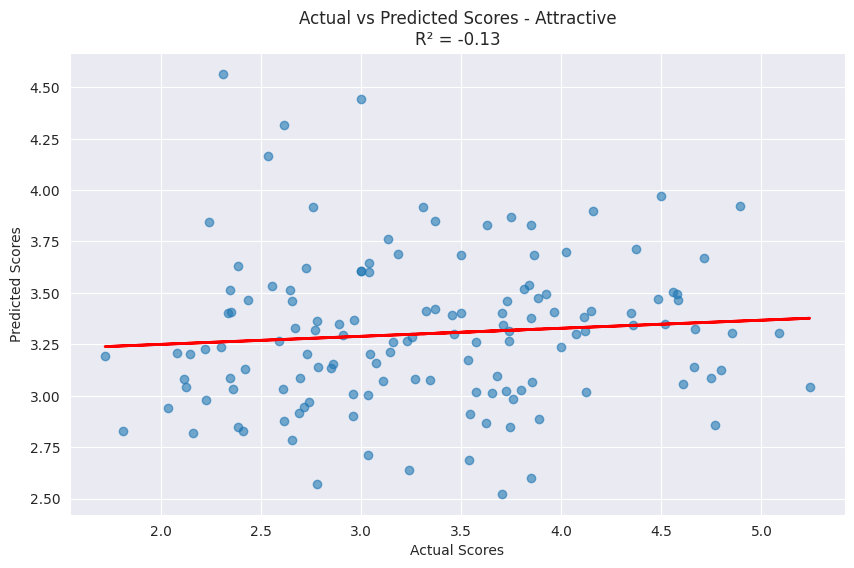

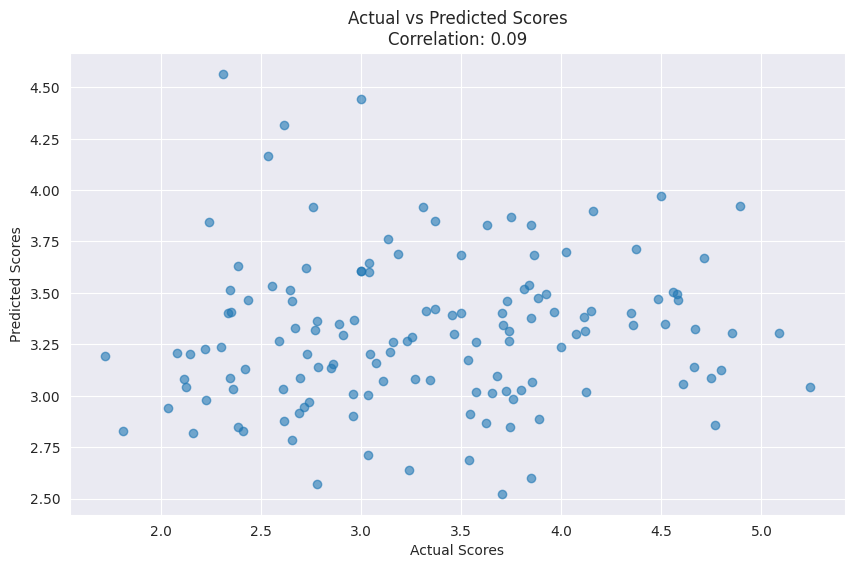

In [20]:
import platform
from pathlib import Path
import joblib
from sklearn.model_selection import train_test_split
from tools.inputs_utils import spreadsheet_to_input_df
from tools.UMAP_utils import train_and_save_umap_and_embeddings
from tools.emuses_utils import DiscreteLatentSpace, compute_stats_on_smoothed_nplusone_dim_discrete_space
from tools.stats_utils import train_model, train_model_kriging, train_model_xgboost_with_fold_grid_search, create_cluster_representative_maps
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from bcblib.tools.visualisation import plot_multiple_rois
from bcblib.tools.general_utils import parse_file_list_argument
from bcblib.tools.arrays_utils import separate_clusters_and_extract_coords


# reload modules
%load_ext autoreload
%autoreload 2

"""
Now the faces dataset
"""

# Detect the operating system
system_name = platform.system()

# Set the base path based on the detected operating system
if system_name == "Windows":
    base_path = Path("S:\GIN Dropbox\Chris Foulon")
else:
    base_path = Path("/gamma/Dropbox (GIN)/")

# Define file paths using the base path
model_path_spreadsheet = base_path / "EMUSE/faces/filtered_files_model_match.csv"
face_input_spreadsheet = base_path / "EMUSE/faces/filtered_face_characteristics_US.csv"
face_scores_spread_sheet = base_path / "EMUSE/faces/filtered_face_attractive_US.csv"
face_output_folder = base_path / "EMUSE/faces/res_EMUSE"

input_df = spreadsheet_to_input_df(str(face_input_spreadsheet), headers=0, index_col=0, columns_are_features=True)
scores_df = pd.read_csv(face_scores_spread_sheet, index_col=0)

# Split the data into training and test sets
train_input_df, test_input_df, train_scores_df, test_scores_df = train_test_split(input_df, scores_df, test_size=0.2, random_state=42)


model_path_df = pd.read_csv(model_path_spreadsheet, header=0, index_col=0)

# print the size and value shape of the train and test dfs
print(f'Train input shape: {train_input_df.shape}, Train scores shape: {train_scores_df.shape}')
print(f'Test input shape: {test_input_df.shape}, Test scores shape: {test_scores_df.shape}')
print(f'Train input value shape: {train_input_df.values.shape}, Train scores value shape: {train_scores_df.values.shape}')
print(f'Test input value shape: {test_input_df.values.shape}, Test scores value shape: {test_scores_df.values.shape}')

faces_input_matrix = train_input_df.values

umap_path = Path(face_output_folder, 'faces_umap_model_joblib1.3.1.joblib')
embeddings_path = Path(face_output_folder, 'faces_embeddings.npy')
if not Path(umap_path).exists():
    trained_umap, embeddings, umap_path, embeddings_path = train_and_save_umap_and_embeddings(faces_input_matrix, face_output_folder, 'faces', random_state=42)
else:
    trained_umap = joblib.load(umap_path)
    embeddings = np.load(embeddings_path)

"""
CREATE DISCRETE SPACE AND HEATMAPS
5% margins around the embeddings
<15% of overlap between the data points
"""
# umap_path = '/gamma/Dropbox (GIN)/EMUSE/DSD_repro/emuse_results/disco_umap_model_joblib1.3.1.joblib'
if True or not Path(face_output_folder, 'faces_dls.dls').exists():
    faces_dls = DiscreteLatentSpace(trained_umap, margin=5) # could use the umap_path

    # rescale the embedding
    faces_dls.rescale_embedding(faces_dls.raw_embeddings)

    # create the discrete space
    faces_dls.create_discrete_space(faces_dls.rescaled_embeddings, 5)

    # create the heatmap spaces with the training AND test datasets combined (for the faces dataset) with disco_dls.trained_umap.transform
    training_embeddings = faces_dls.trained_umap.transform(train_input_df.values)

    np.save(Path(face_output_folder, 'training_embeddings.npy'), training_embeddings)

    test_embeddings = faces_dls.trained_umap.transform(test_input_df.values)

    np.save(Path(face_output_folder, 'test_embeddings.npy'), test_embeddings)

    faces_dls.save(Path(face_output_folder, 'faces_dls.dls'))
else:
    faces_dls = DiscreteLatentSpace.load(Path(face_output_folder, 'faces_dls.dls'))
    training_embeddings = np.load(Path(face_output_folder, 'training_embeddings.npy'))
    test_embeddings = np.load(Path(face_output_folder, 'test_embeddings.npy'))

# plot embeddings
plt.figure(figsize=(10, 7))
plt.scatter(embeddings[:, 0], embeddings[:, 1], c='b', s=10)
plt.title('UMAP Embeddings')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.show()

discrete_embeddings = faces_dls.discrete_embeddings

plt.figure(figsize=(10, 10))
plt.scatter(discrete_embeddings[:, 0], discrete_embeddings[:, 1], c='b', s=10)
plt.axis('scaled')
plt.xlim(0, plt.xlim()[1])  # Set x-axis to start at 0
plt.ylim(0, plt.ylim()[1])  # Set y-axis to start at 0
plt.title('UMAP Discrete Latent Space')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.savefig('/gamma/Dropbox (GIN)/EMUSE/faces/res_EMUSE/discrete_umap_embeddings.png')
plt.show()

# Process for the single score 'Attractive'
score_tag = 'Attractive'
score_output_folder = Path(face_output_folder, score_tag)
Path(score_output_folder).mkdir(parents=True, exist_ok=True)

# Prepare DataFrames for training and test sets
train_scores = train_scores_df[score_tag].to_numpy()
train_df = pd.DataFrame(data={'embeddings': [tuple(coord) for coord in training_embeddings]})
train_df['scores'] = train_scores

test_scores = test_scores_df[score_tag].to_numpy()
test_df = pd.DataFrame(data={'embeddings': [tuple(coord) for coord in test_embeddings]})
test_df['scores'] = test_scores

# Create heatmap for the combined dataset
if score_tag in faces_dls.heatmaps:
    faces_dls.delete_heatmap(score_tag)
if score_tag not in faces_dls.heatmaps:
    faces_dls.create_heatmap_spaces(train_df, score_tag, smoothing_fwhm=None, smoothing_sigma=20)

print(f'Heatmap {score_tag} created')

faces_attractive_3d_dls = faces_dls.heatmaps[score_tag].smoothed_nplusone_dim_discrete_space

faces_dls.plot_heatmap(score_tag, output_folder=score_output_folder)

# Now we compute the correlations and display the heatmaps for each score
statistics, pvalues, corrected_pvalues, reject = compute_stats_on_smoothed_nplusone_dim_discrete_space(
    faces_dls.heatmaps[score_tag], faces_dls.heatmaps[score_tag].scores, correction_method='holm')

print(f'Statistics for {score_tag} computed')

# Plot the statistics
plt.figure(figsize=(10, 7))
plt.imshow(statistics.T, cmap='viridis', origin='lower')
plt.colorbar(label='Statistics')
plt.title(f'Statistics for {score_tag}')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.savefig(Path(score_output_folder, f'raw_statistics_{score_tag}.png'))
plt.show()

# Threshold the |statistics| > 0.2 and show the space
thresholded_statistics = np.where(np.abs(statistics) < 0.2, np.nan, statistics)
plt.figure(figsize=(10, 7))
plt.imshow(thresholded_statistics.T, cmap='viridis', origin='lower')
plt.colorbar(label='Thresholded Statistics')
plt.title(f'Thresholded Statistics for {score_tag}')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.savefig(Path(score_output_folder, f'thresholded_statistics_{score_tag}.png'))
plt.show()

# Create a mask for the rejected hypotheses
reject_mask = np.ma.masked_where(corrected_pvalues > 0.05, statistics)

# Plot the statistics that are not rejected
plt.figure(figsize=(10, 7))
plt.imshow(reject_mask.T, cmap='viridis', origin='lower')
plt.colorbar(label='Non-rejected Statistics')
plt.title(f'Non-rejected Statistics for {score_tag}')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.savefig(Path(score_output_folder, f'non_rejected_statistics_{score_tag}.png'))
plt.show()

# Create cluster representative maps
stat_maps, pval_maps, effect_size_maps, centroids = create_cluster_representative_maps(
    thresholded_statistics, faces_dls.discrete_embeddings, faces_input_matrix, (input_df.shape[1]), test_name='mann-whitney')

# now each map contains an array with a value for each feature
# So, for each map in stat_map, pval_map, effect_size_map, create a dataframe with the feature names as the index and the values as the columns and save it as a csv with the _x_y centroid coordinates in the name
for stat_map, pval_map, effect_size_map, centroid in zip(stat_maps, pval_maps, effect_size_maps, centroids):
    # create one dataframe with the three values as columns
    tests_df = pd.DataFrame(data={'Statistics': stat_map, 'P-Values': pval_map, 'Effect Size': effect_size_map})
    # save the dataframe as a csv
    tests_df.to_csv(Path(score_output_folder, f'tests_{score_tag}_{centroid[0]}_{centroid[1]}.csv'))

# create an output folder for each prediction model (random forest, kriging, xgboost)
rf_output_folder = Path(score_output_folder, 'random_forest')
Path(rf_output_folder).mkdir(parents=True, exist_ok=True)
krigin_output_folder = Path(score_output_folder, 'kriging')
Path(krigin_output_folder).mkdir(parents=True, exist_ok=True)
xgboost_output_folder = Path(score_output_folder, 'xgboost')
Path(xgboost_output_folder).mkdir(parents=True, exist_ok=True)
# Now train and validate the predictive model
# train_model_kriging(train_df, test_df, score_tag, krigin_output_folder)
train_model(train_df, test_df, score_tag, rf_output_folder)
# train_model_xgboost_with_fold_grid_search(train_df, test_df, score_tag, xgboost_output_folder)

In [40]:
import pandas as pd

# Load the data
handsome_df = pd.read_csv('/gamma/Dropbox (GIN)/EMUSE/faces/res_EMUSE/Attractive/tests_Attractive_23.656185919343812_212.6678058783322.csv', index_col=0)
face_input_spreadsheet = pd.read_csv('/gamma/Dropbox (GIN)/EMUSE/faces/filtered_face_characteristics_US.csv', index_col=0, header=0)

# Filter the dataframe based on the condition
filtered_handsome_df = handsome_df[handsome_df['Effect Size'] > 0.2]

# print the columns corresponding the indices in filtered_handsome_df
print(face_input_spreadsheet.columns[filtered_handsome_df.index])

print(filtered_handsome_df)

# Replace the indices with the actual column names
filtered_handsome_df.index = face_input_spreadsheet.columns[filtered_handsome_df.index]

# Display the table
print(filtered_handsome_df)


Index(['PupilTopAsymmetry', 'Heartshapeness', 'UpperHeadLength',
       'ForeheadHeight'],
      dtype='object')
    Statistics      P-Values  Effect Size
18    7.226393  4.922448e-13     0.308696
31    6.781594  1.194356e-11     0.289695
36    5.273637  1.342597e-07     0.225279
39    7.484278  7.232752e-14     0.319712
                   Statistics      P-Values  Effect Size
PupilTopAsymmetry    7.226393  4.922448e-13     0.308696
Heartshapeness       6.781594  1.194356e-11     0.289695
UpperHeadLength      5.273637  1.342597e-07     0.225279
ForeheadHeight       7.484278  7.232752e-14     0.319712


In [14]:
# /gamma/Dropbox (GIN)/EMUSE/faces/res_EMUSE/Attractive/tests_Attractive_203.140350877193_204.65856950067476.csv
ugly_df = pd.read_csv('/gamma/Dropbox (GIN)/EMUSE/faces/res_EMUSE/Attractive/tests_Attractive_302.3032786885246_303.650521609538.csv', index_col=0)

# the indices in ugly_df are the columns in face_input_spreadsheet.
# print all the column names of face_input_spreadsheet where ugly_df['Effect Size'] > 0.2 and their values
print(face_input_spreadsheet.columns[ugly_df['Effect Size'] > 0.2])
print(ugly_df[ugly_df['Effect Size'] > 0.2])

Index(['FaceShape', 'FaceRoundness', 'fWHR2'], dtype='object')
    Statistics      P-Values  Effect Size
30    5.707352  1.152327e-08     0.243806
41    5.480037  4.269696e-08     0.234096
42    5.690088  1.275088e-08     0.243069


['mes_coc']
(79, 302, 261)


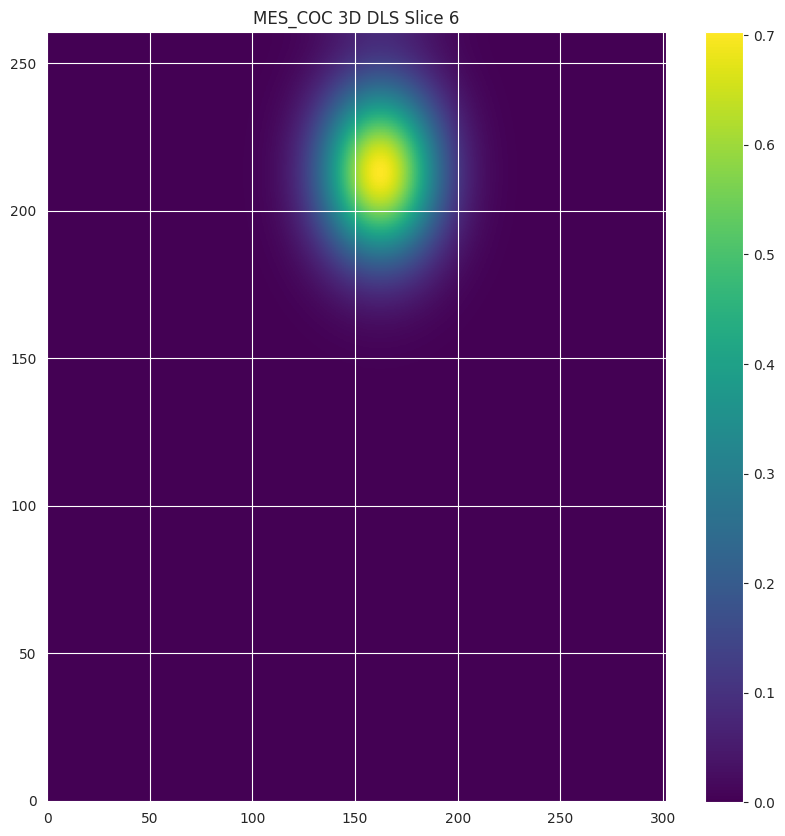

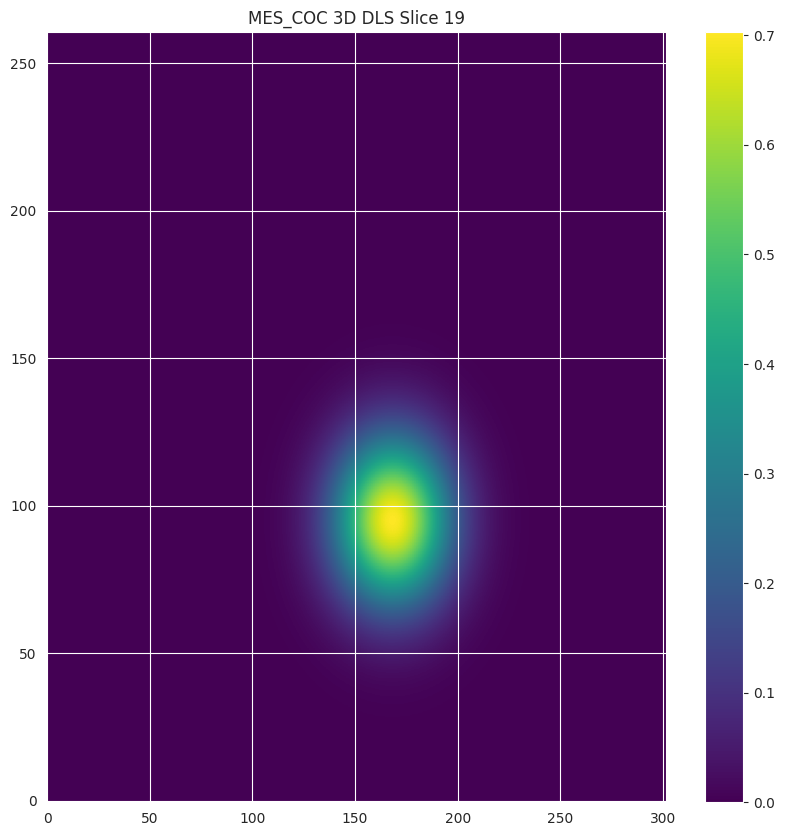

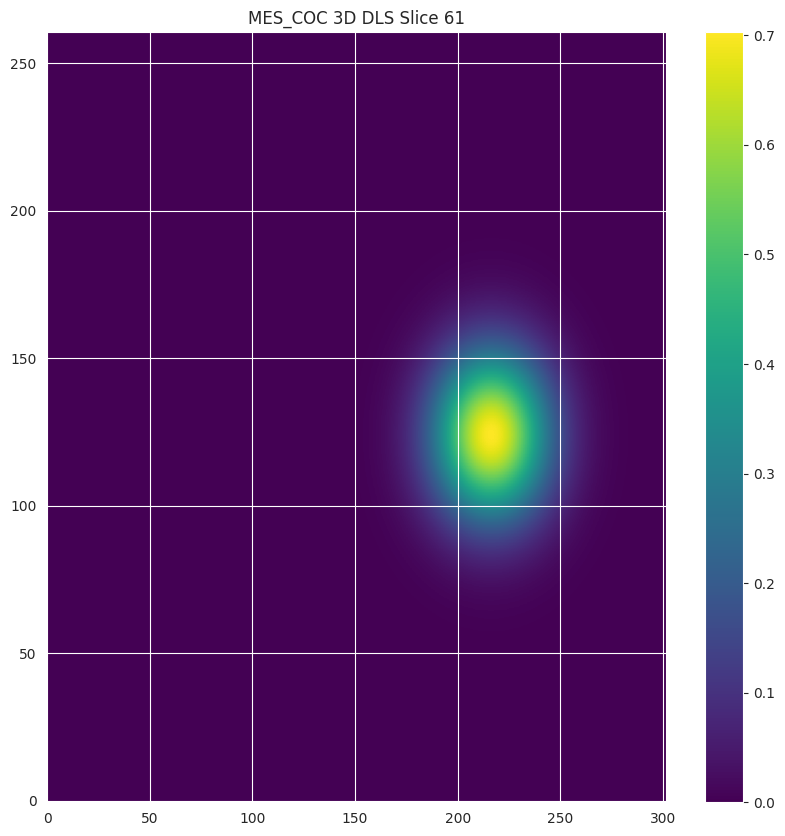

In [46]:
print(list(disco_dls.heatmaps.keys()))

mes_coc_3d_dls = disco_dls.heatmaps['mes_coc'].smoothed_nplusone_dim_discrete_space
print(mes_coc_3d_dls.shape)

output_temp_folder = '/gamma/Dropbox (GIN)/EMUSE/DSD_repro/emuse_results_all_scores_100_permutation_better_plots_temp'
Path(output_temp_folder).mkdir(parents=True, exist_ok=True)

# plot 3 random slices (random indices in the 0 dim) of the 3d_dls and save them
rand_ind = np.random.randint(0, mes_coc_3d_dls.shape[0], 3)
for i, ind in enumerate(rand_ind):
    plt.figure(figsize=(10, 10))
    plt.imshow(mes_coc_3d_dls[ind, :, :].T, cmap='viridis', origin='lower', aspect='auto')
    plt.colorbar()
    plt.title(f'MES_COC 3D DLS Slice {ind}')
    plt.savefig(Path(output_temp_folder, f'mes_coc_3d_dls_slice_{ind}.png'))
    plt.show()
